# Assignment 3: Classification Models and Evaluation Metrics
## Business Account Upgrade Prediction Using Logistic Regression and SVM

**Course:** MBAI 5310G – AI Programming  
**Assignment:** Assignment 3  
**Dataset:** `business_account_upgrade_prediction_dataset`  
**Target variable:** `Upgraded_Account`  
**Models compared:** Logistic Regression and Support Vector Machine (SVM)

# Introduction and Assignment Objective

This notebook trains and compares two classification models for a business account upgrade prediction problem. The purpose of the models is to predict whether a business account is likely to upgrade its account or not.

The assignment focuses on both technical model evaluation and business interpretation. Therefore, the notebook follows a clear machine learning workflow: understanding the business problem, loading and inspecting the dataset, preparing the data, separating features and target, splitting the data into training and testing sets, applying preprocessing, training Logistic Regression and SVM models, evaluating both models, comparing their results, and explaining the business meaning of the findings.

The two classification models used in this notebook are Logistic Regression and Support Vector Machine (SVM). Both models are evaluated using confusion matrix, accuracy, precision, recall, and F1-score. The final section compares the two models and explains which model performs better for the business problem.

## Step 1: Business Problem and Dataset Overview

Many companies offer different account plans or service levels to their business customers. Some business accounts remain on their current plan, while others upgrade to a higher-value account. Identifying which accounts are more likely to upgrade can help the company improve sales planning, customer success support, training programs, and targeted marketing activities.

The main business problem is account upgrade prediction. Some accounts may show signs that they are more likely to upgrade, such as higher revenue, more monthly transactions, stronger product usage, sales contact, training attendance, or longer account relationships.

The business question is:

Can the company predict whether a business account will upgrade using account information, revenue details, transaction activity, product usage, support history, sales contact information, and training-related indicators?

The machine learning models can help the company identify accounts that may be suitable for sales follow-up, product demonstrations, account reviews, training support, or targeted upgrade offers.

The dataset used in this notebook contains business account information. Each row represents one business account. The dataset includes variables such as company size, industry, annual revenue, monthly transactions, current plan, account age, support tickets, sales contact status, product usage score, monthly fee, training attendance, and upgrade outcome.

Because the outcome has two possible classes, this is a supervised binary classification problem.

In [1]:
# Step 0: Import Required Libraries

# Import pandas for data handling
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for charts
import matplotlib.pyplot as plt

# Import Path to work with file and folder paths
from pathlib import Path

# Import display tools for showing tables and images clearly
from IPython.display import display, Image

# Import train_test_split for splitting the dataset
from sklearn.model_selection import train_test_split

# Import preprocessing tools
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Import classification models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Import evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Create the outputs folder for saving charts
outputs_dir = Path("outputs")
outputs_dir.mkdir(exist_ok=True)

# Print confirmation message
print("Libraries imported successfully.")
print("Outputs folder is ready.")

Libraries imported successfully.
Outputs folder is ready.


## Step 2: Loading the Dataset

In this step, the business account upgrade prediction dataset is loaded into Python.

The dataset file used in this notebook is named `business_account_upgrade_prediction_dataset.xls`. Although the file name appears with an `.xls` extension, the data is stored in a comma-separated format. Therefore, the dataset is loaded using `pd.read_csv()` instead of `pd.read_excel()`.

To make the notebook reproducible, the dataset should be saved in the same folder as this notebook. A hard-coded computer path is avoided because it may not work on another computer or when the notebook is uploaded to GitHub.

In [2]:
# Step 2: Load the Dataset

# Store the dataset file name
file_path = r"C:\Users\Praba\OneDrive\Desktop\business_account_upgrade_prediction_dataset.xls"

# Load the dataset using read_csv because the file is comma-separated
df = pd.read_csv(file_path)

# Clean column names by removing extra spaces
df.columns = df.columns.str.strip()

# Print confirmation message
print("Dataset loaded successfully!")

# Display the dataset shape
print("Dataset shape:", df.shape)

# Display the first five rows
display(df.head())

Dataset loaded successfully!
Dataset shape: (377, 13)


,Account_ID,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended,Upgraded_Account
0,1,Small,Healthcare,4765975.0,368,Business,26,5,No,55.0,2832,Yes,No
1,2,Small,Manufacturing,5683548.0,257,Basic,75,4,No,5.0,1215,Yes,No
2,3,Enterprise,Manufacturing,1722517.0,424,Premium,99,0,No,64.0,753,No,No
3,4,Enterprise,Education,3481277.0,190,Standard,33,0,Yes,86.0,1973,No,Yes
4,5,Small,Finance,1023375.0,262,Basic,52,3,No,88.0,3676,Yes,No


## Step 3: Initial Data Inspection

After loading the dataset, we inspect it carefully before cleaning and model training. This step helps us understand the structure, size, and quality of the business account upgrade prediction dataset.

In this step, we display the first and last five rows of the dataset to check whether the data has loaded correctly. We also check the number of rows and columns, column names, data types, missing values, duplicate rows, summary statistics, and the distribution of the target variable.

Initial data inspection is important because classification models require clean, complete, and well-structured data. If the dataset contains missing values, duplicate records, incorrect data types, or class imbalance, the model may produce unreliable or misleading results.

Checking the target variable distribution is also important because imbalanced classes can affect model evaluation. For example, if one class appears much more often than the other, accuracy alone may not fully explain how well the model performs.


In [3]:
# Display the first five rows of the dataset
display(df.head())

,Account_ID,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended,Upgraded_Account
0,1,Small,Healthcare,4765975.0,368,Business,26,5,No,55.0,2832,Yes,No
1,2,Small,Manufacturing,5683548.0,257,Basic,75,4,No,5.0,1215,Yes,No
2,3,Enterprise,Manufacturing,1722517.0,424,Premium,99,0,No,64.0,753,No,No
3,4,Enterprise,Education,3481277.0,190,Standard,33,0,Yes,86.0,1973,No,Yes
4,5,Small,Finance,1023375.0,262,Basic,52,3,No,88.0,3676,Yes,No


In [4]:
# Display the last five rows of the dataset
display(df.tail())

,Account_ID,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended,Upgraded_Account
372,314,Large,Education,4054009.0,125,Basic,99,6,No,56.0,3005,No,No
373,261,Small,Finance,5943853.0,190,Business,116,10,Yes,58.0,172,No,No
374,272,Small,Technology,6513840.0,301,Standard,92,9,Yes,69.0,983,Yes,Yes
375,222,Enterprise,Technology,2754584.0,409,Standard,85,5,Yes,95.0,504,No,Yes
376,49,Small,Technology,7512369.0,176,Basic,101,4,Yes,55.0,279,No,No


In [5]:
# Show the number of rows and columns
print("Number of rows and columns:")
print(df.shape)

Number of rows and columns:
(377, 13)


In [6]:
# Display the column names in the dataset
print("Column names:")
print(df.columns.tolist())

Column names:
['Account_ID', 'Company_Size', 'Industry', 'Annual_Revenue', 'Monthly_Transactions', 'Current_Plan', 'Account_Age_Months', 'Support_Tickets', 'Sales_Contacted', 'Product_Usage_Score', 'Monthly_Fee', 'Training_Attended', 'Upgraded_Account']


In [7]:
# Show general information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 377 entries, 0 to 376
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Account_ID            377 non-null    int64  
 1   Company_Size          370 non-null    str    
 2   Industry              370 non-null    str    
 3   Annual_Revenue        370 non-null    float64
 4   Monthly_Transactions  377 non-null    int64  
 5   Current_Plan          370 non-null    str    
 6   Account_Age_Months    377 non-null    int64  
 7   Support_Tickets       377 non-null    int64  
 8   Sales_Contacted       370 non-null    str    
 9   Product_Usage_Score   370 non-null    float64
 10  Monthly_Fee           377 non-null    int64  
 11  Training_Attended     377 non-null    str    
 12  Upgraded_Account      377 non-null    str    
dtypes: float64(2), int64(5), str(6)
memory usage: 49.1 KB


In [8]:
# Print a title for this output
print("Data Types of Each Column")

# Print a separator line
print("-" * 50)

# Display the data type of each column
display(df.dtypes)

Data Types of Each Column
--------------------------------------------------


Account_ID                int64
Company_Size                str
Industry                    str
Annual_Revenue          float64
Monthly_Transactions      int64
Current_Plan                str
Account_Age_Months        int64
Support_Tickets           int64
Sales_Contacted             str
Product_Usage_Score     float64
Monthly_Fee               int64
Training_Attended           str
Upgraded_Account            str
dtype: object

In [9]:
# Print a title for this output
print("Missing Values in Each Column")

# Print a separator line
print("-" * 50)

# Count missing values in each column
missing_values = df.isnull().sum()

# Display missing values
display(missing_values)

Missing Values in Each Column
--------------------------------------------------


Account_ID              0
Company_Size            7
Industry                7
Annual_Revenue          7
Monthly_Transactions    0
Current_Plan            7
Account_Age_Months      0
Support_Tickets         0
Sales_Contacted         7
Product_Usage_Score     7
Monthly_Fee             0
Training_Attended       0
Upgraded_Account        0
dtype: int64

In [10]:
# Print a title for this output
print("Number of Duplicate Rows")

# Print a separator line
print("-" * 50)

# Count duplicate rows
duplicate_rows = df.duplicated().sum()

# Display duplicate row count
print(duplicate_rows)

Number of Duplicate Rows
--------------------------------------------------
7


In [11]:
# Show summary statistics for numerical columns
display(df.describe())

,Account_ID,Annual_Revenue,Monthly_Transactions,Account_Age_Months,Support_Tickets,Product_Usage_Score,Monthly_Fee
count,377.000000,3.700000e+02,377.000000,377.000000,377.000000,370.000000,377.000000
mean,186.265252,4.060962e+06,248.880637,60.962865,6.933687,51.102703,2408.000000
std,106.726653,2.315737e+06,140.723205,35.513763,4.266190,28.988835,1430.944912
min,1.000000,8.265600e+04,0.000000,1.000000,0.000000,0.000000,83.000000
25%,94.000000,1.902595e+06,130.000000,30.000000,4.000000,27.000000,1231.000000
50%,187.000000,4.182715e+06,248.000000,62.000000,7.000000,51.500000,2414.000000
75%,278.000000,6.017136e+06,363.000000,93.000000,10.000000,76.000000,3623.000000
max,370.000000,7.987036e+06,499.000000,119.000000,14.000000,100.000000,4999.000000


In [12]:
# Print a title for this output
print("Summary Statistics for Categorical Columns")

# Print a separator line
print("-" * 50)

# Display summary statistics for categorical/text columns
display(df.describe(include=["object","string"]))

Summary Statistics for Categorical Columns
--------------------------------------------------


,Company_Size,Industry,Current_Plan,Sales_Contacted,Training_Attended,Upgraded_Account
count,370,370,370,370,377,377
unique,4,6,4,2,2,2
top,Small,Technology,Basic,No,No,No
freq,158,74,132,200,200,293


## Step 4: Data Cleaning

Before training the classification models, the dataset needs to be cleaned to reduce data quality issues.

In this step, we first create a copy of the original dataset so that the raw data remains unchanged. Then, duplicate rows are checked and removed if they exist.

Duplicate rows can affect model performance because repeated records may give extra weight to the same information during training.

Missing values are checked in this section, but they will be handled later inside the preprocessing pipeline. This keeps the workflow cleaner and helps avoid data leakage.


In [13]:
# Step 4: Data Cleaning

# Create a copy of the original dataset
df_clean = df.copy()

# Check duplicate rows before cleaning
duplicates_before = df_clean.duplicated().sum()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Check duplicate rows after cleaning
duplicates_after = df_clean.duplicated().sum()

# Display duplicate cleaning summary
print("Duplicate rows before cleaning:", duplicates_before)
print("Duplicate rows after cleaning:", duplicates_after)
# Show the shape of the original dataset
print("Original dataset shape:", df.shape)
print("Dataset shape after removing duplicates:", df_clean.shape)

# Check missing values after duplicate removal
missing_values_after_duplicates = df_clean.isnull().sum()

# Display columns with missing values only
print("\nMissing values after duplicate removal:")
print(missing_values_after_duplicates[missing_values_after_duplicates > 0])

Duplicate rows before cleaning: 7
Duplicate rows after cleaning: 0
Original dataset shape: (377, 13)
Dataset shape after removing duplicates: (370, 13)

Missing values after duplicate removal:
Company_Size           7
Industry               7
Annual_Revenue         7
Current_Plan           7
Sales_Contacted        7
Product_Usage_Score    7
dtype: int64


In [14]:
# Display the first five rows of the cleaned dataset
display(df_clean.head())

,Account_ID,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended,Upgraded_Account
0,1,Small,Healthcare,4765975.0,368,Business,26,5,No,55.0,2832,Yes,No
1,2,Small,Manufacturing,5683548.0,257,Basic,75,4,No,5.0,1215,Yes,No
2,3,Enterprise,Manufacturing,1722517.0,424,Premium,99,0,No,64.0,753,No,No
3,4,Enterprise,Education,3481277.0,190,Standard,33,0,Yes,86.0,1973,No,Yes
4,5,Small,Finance,1023375.0,262,Basic,52,3,No,88.0,3676,Yes,No


### Short Interpretation

Duplicate rows have been removed from the dataset. This helps prevent repeated business account records from giving extra weight to the same information during model training.

The dataset is now cleaned for duplicate records. Missing values have been checked and will be handled later inside the preprocessing pipeline.

## Step 5: Missing Value Inspection and Handling Strategy

In this step, we check missing values in the cleaned dataset.

Missing values can cause errors during model training because Logistic Regression and SVM cannot work with empty cells. However, instead of filling missing values directly in the full dataset, missing-value handling will be included inside the preprocessing pipeline.

For numerical features, missing values will be filled using the median. For categorical features, missing values will be filled using the most frequent category.

This approach is better because the imputation values are learned from the training data only and then applied to the testing data. This helps avoid data leakage and keeps the modeling process more reliable.

In [15]:
# Step 5: Missing Value Inspection and Handling Strategy

target_column = "Upgraded_Account"
id_column = "Account_ID"
# Count missing values before preprocessing
missing_before = df_clean.isnull().sum()

# Display missing values before preprocessing
print("Missing Values Before Preprocessing")
print("-" * 50)
display(missing_before[missing_before > 0])

# Select feature columns only, excluding ID and target columns
feature_columns_for_missing_check = df_clean.drop(
    columns=[target_column, id_column],
    errors="ignore"
)

# Select numerical feature columns
numerical_columns_for_cleaning = feature_columns_for_missing_check.select_dtypes(
    include=["number"]
).columns.tolist()

# Select categorical feature columns
categorical_columns_for_cleaning = feature_columns_for_missing_check.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

# Create an empty list to store the missing value handling plan
missing_value_handling_plan = []

# Create handling plan for numerical columns
for column in numerical_columns_for_cleaning:
    missing_count = df_clean[column].isnull().sum()

    if missing_count > 0:
        missing_value_handling_plan.append(
            [column, "Numerical", missing_count, "Median", "Handled later inside preprocessing pipeline"]
        )

# Create handling plan for categorical columns
for column in categorical_columns_for_cleaning:
    missing_count = df_clean[column].isnull().sum()

    if missing_count > 0:
        missing_value_handling_plan.append(
            [column, "Categorical", missing_count, "Most frequent value", "Handled later inside preprocessing pipeline"]
        )

# Convert missing value handling plan into a DataFrame
missing_value_handling_plan = pd.DataFrame(
    missing_value_handling_plan,
    columns=["Column", "Data Type", "Missing Values", "Planned Method", "Handling Location"]
)

# Display the missing value handling plan
print("Missing Value Handling Plan")
print("-" * 50)
display(missing_value_handling_plan)

# Save the missing value handling plan
missing_value_handling_plan.to_csv(
    outputs_dir / "missing_value_handling_plan.csv",
    index=False
)

print("Missing values will be handled later inside the preprocessing pipeline.")

Missing Values Before Preprocessing
--------------------------------------------------


Company_Size           7
Industry               7
Annual_Revenue         7
Current_Plan           7
Sales_Contacted        7
Product_Usage_Score    7
dtype: int64

Missing Value Handling Plan
--------------------------------------------------


,Column,Data Type,Missing Values,Planned Method,Handling Location
0,Annual_Revenue,Numerical,7,Median,Handled later inside preprocessing pipeline
1,Product_Usage_Score,Numerical,7,Median,Handled later inside preprocessing pipeline
2,Company_Size,Categorical,7,Most frequent value,Handled later inside preprocessing pipeline
3,Industry,Categorical,7,Most frequent value,Handled later inside preprocessing pipeline
4,Current_Plan,Categorical,7,Most frequent value,Handled later inside preprocessing pipeline
5,Sales_Contacted,Categorical,7,Most frequent value,Handled later inside preprocessing pipeline


Missing values will be handled later inside the preprocessing pipeline.


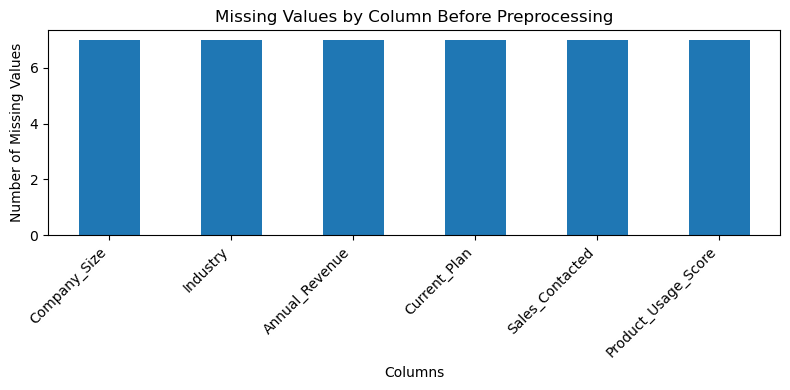

In [16]:
# Create a chart for missing values before preprocessing

# Select only columns that have missing values
missing_columns = missing_before[missing_before > 0]

# Create a bar chart only if there are columns with missing values
if len(missing_columns) > 0:
    
    # Create a figure for the missing values chart
    plt.figure(figsize=(8, 4))

    # Create a bar chart for columns with missing values
    missing_columns.plot(kind="bar")

    # Add a title to the chart
    plt.title("Missing Values by Column Before Preprocessing")

    # Add a label to the x-axis
    plt.xlabel("Columns")

    # Add a label to the y-axis
    plt.ylabel("Number of Missing Values")

    # Rotate x-axis labels to make them easier to read
    plt.xticks(rotation=45, ha="right")

    # Adjust the layout so labels do not overlap
    plt.tight_layout()

    # Save the chart in the outputs folder
    plt.savefig(outputs_dir / "missing_values_by_column.png", dpi=300, bbox_inches="tight")

    # Display the chart
    plt.show()

else:
    print("No missing values found before preprocessing.")

In [17]:
# Print cleaned dataset shape
print("Cleaned Dataset Shape")

# Print a separator line
print("-" * 50)

# Display the shape of the cleaned dataset
print(df_clean.shape)

Cleaned Dataset Shape
--------------------------------------------------
(370, 13)


## Step 6: Understanding Features, Target Variable, and Target Distribution

After inspecting the dataset, the next step is to understand the input features, the target variable, and the distribution of the target classes.

In this assignment, the target variable is Upgraded_Account. This is the column that the models will try to predict. It shows whether a business account upgraded or did not upgrade.

The target variable has two possible classes:

Yes: The business account upgraded.
No: The business account did not upgrade.

All other meaningful business columns are considered input features. These features may include company size, industry, annual revenue, monthly transactions, current plan, account age, support tickets, sales contact status, product usage score, monthly fee, and training attendance.

The Account_ID column is not used as a feature because it is only an identifier. It does not explain account behaviour or provide useful predictive information for the model.

Understanding the target distribution is important because it shows whether the dataset is balanced or imbalanced. If one class appears much more often than the other, accuracy alone may not be enough to evaluate the model. In that case, precision, recall, and F1-score become especially important for understanding how well the models predict upgraded accounts.

In [18]:
# Define the target column
target_column = "Upgraded_Account"

# Define the ID column
id_column = "Account_ID"

# Print the target variable
print("Target Variable")

# Print a separator line
print("-" * 50)

# Display the target variable name
print(target_column)

Target Variable
--------------------------------------------------
Upgraded_Account


In [19]:
# Print the unique values in the target variable
print("Target Variable Values")

# Print a separator line
print("-" * 50)

# Display unique target values as a clean list
print(df_clean[target_column].unique().tolist())

Target Variable Values
--------------------------------------------------
['No', 'Yes']


In [20]:
# Create a list of input feature columns by removing the target column and ID column
input_features = df_clean.drop(columns=[target_column, id_column]).columns.tolist()

# Print a title
print("Input Feature Columns")

# Print a separator line
print("-" * 50)

# Display input feature columns
print(input_features)

Input Feature Columns
--------------------------------------------------
['Company_Size', 'Industry', 'Annual_Revenue', 'Monthly_Transactions', 'Current_Plan', 'Account_Age_Months', 'Support_Tickets', 'Sales_Contacted', 'Product_Usage_Score', 'Monthly_Fee', 'Training_Attended']


In [21]:
# Count the number of records in each target class
target_distribution = df_clean[target_column].value_counts()

# Print a title
print("Target Class Distribution")

# Print a separator line
print("-" * 50)

# Display the target class distribution
display(target_distribution)

Target Class Distribution
--------------------------------------------------


Upgraded_Account
No     288
Yes     82
Name: count, dtype: int64

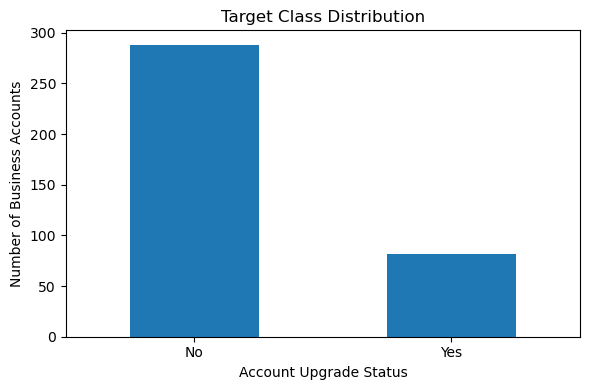

In [22]:
# Create a bar chart for target class distribution
plt.figure(figsize=(6, 4))

# Plot the target class distribution
target_distribution.plot(kind="bar")

# Add chart title and labels
plt.title("Target Class Distribution")
plt.xlabel("Account Upgrade Status")
plt.ylabel("Number of Business Accounts")

# Rotate x-axis labels
plt.xticks(rotation=0)

# Adjust the layout
plt.tight_layout()

# Save the chart
plt.savefig("outputs/target_class_distribution.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

### Short Interpretation

The target variable Upgraded_Account has two classes: Yes and No. This confirms that the task is a binary classification problem because the model is predicting one of two possible outcomes.

The target distribution chart shows how many business accounts upgraded and how many did not upgrade. This is important because if one class appears much more often than the other, the dataset may be imbalanced. In that case, accuracy alone may not be enough to evaluate the models, and metrics such as precision, recall, and F1-score should also be considered.

## Step 7: Understanding Numerical and Categorical Variables

In this step, we separate the input features into numerical and categorical variables. This is important because different types of variables require different preprocessing methods before model training.

Numerical variables contain number-based values, such as revenue, monthly transactions, account age, support tickets, product usage score, and monthly fee. These variables can be scaled so that large-value columns do not dominate smaller-value columns.

Categorical variables contain text-based groups, such as company size, industry, current plan, sales contact status, and training attendance. These variables need to be converted into numerical format before they can be used by Logistic Regression and SVM models.

Identifying numerical and categorical variables helps us build a proper preprocessing pipeline for both models.


In [23]:
# Create a feature-only dataset by removing the target column and ID column
feature_data = df_clean.drop(columns=[target_column, id_column])

# Select numerical feature columns
numerical_features_initial = feature_data.select_dtypes(include=["number"]).columns.tolist()

# Select categorical feature columns
categorical_features_initial = feature_data.select_dtypes(include=["object","string"]).columns.tolist()

# Print numerical feature columns
print("Numerical Feature Columns")
print("-" * 50)
print(numerical_features_initial)

# Print categorical feature columns
print("\nCategorical Feature Columns")
print("-" * 50)
print(categorical_features_initial)

Numerical Feature Columns
--------------------------------------------------
['Annual_Revenue', 'Monthly_Transactions', 'Account_Age_Months', 'Support_Tickets', 'Product_Usage_Score', 'Monthly_Fee']

Categorical Feature Columns
--------------------------------------------------
['Company_Size', 'Industry', 'Current_Plan', 'Sales_Contacted', 'Training_Attended']


In [24]:
# Create a table showing the number of numerical and categorical features
feature_type_summary = pd.DataFrame({
    "Feature Type": ["Numerical", "Categorical"],
    "Number of Features": [len(numerical_features_initial), len(categorical_features_initial)]
})

# Display the feature type summary table
display(feature_type_summary)

,Feature Type,Number of Features
0,Numerical,6
1,Categorical,5


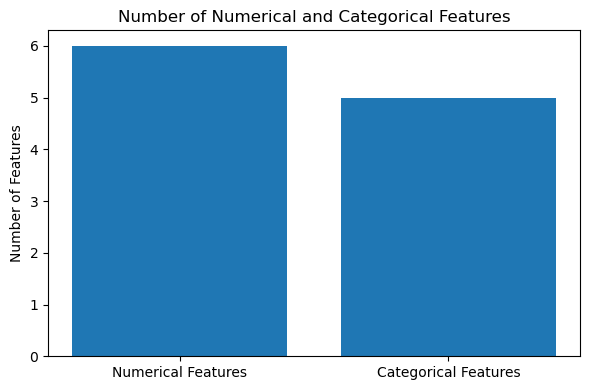

In [25]:
# Create labels for the chart
feature_type_labels = ["Numerical Features", "Categorical Features"]

# Create values for the chart using the feature lists
feature_type_counts = [
    len(numerical_features_initial),
    len(categorical_features_initial)
]

# Create a figure for the chart
plt.figure(figsize=(6, 4))

# Create a bar chart
plt.bar(feature_type_labels, feature_type_counts)

# Add a chart title
plt.title("Number of Numerical and Categorical Features")

# Add a label to the y-axis
plt.ylabel("Number of Features")

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

In [26]:
# Print a title for unique values
print("Unique values in categorical features")
print("-" * 50)

# Loop through each categorical feature
for column in categorical_features_initial:
    
    # Print the column name
    print("Column:", column)
    
    # Print the unique values in the column
    print(df_clean[column].unique().tolist())
    
    # Print a separator line
    print("-" * 50)

Unique values in categorical features
--------------------------------------------------
Column: Company_Size
['Small', 'Enterprise', 'Large', 'Medium', nan]
--------------------------------------------------
Column: Industry
['Healthcare', 'Manufacturing', 'Education', 'Finance', 'Technology', 'Retail', nan]
--------------------------------------------------
Column: Current_Plan
['Business', 'Basic', 'Premium', 'Standard', nan]
--------------------------------------------------
Column: Sales_Contacted
['No', 'Yes', nan]
--------------------------------------------------
Column: Training_Attended
['Yes', 'No']
--------------------------------------------------


In [27]:
# Count unique values for each categorical feature
categorical_unique_counts = feature_data[categorical_features_initial].nunique()

# Print a title
print("Number of Unique Values in Each Categorical Feature")

# Print a separator line
print("-" * 50)

# Display the number of unique values
display(categorical_unique_counts)

Number of Unique Values in Each Categorical Feature
--------------------------------------------------


Company_Size         4
Industry             6
Current_Plan         4
Sales_Contacted      2
Training_Attended    2
dtype: int64

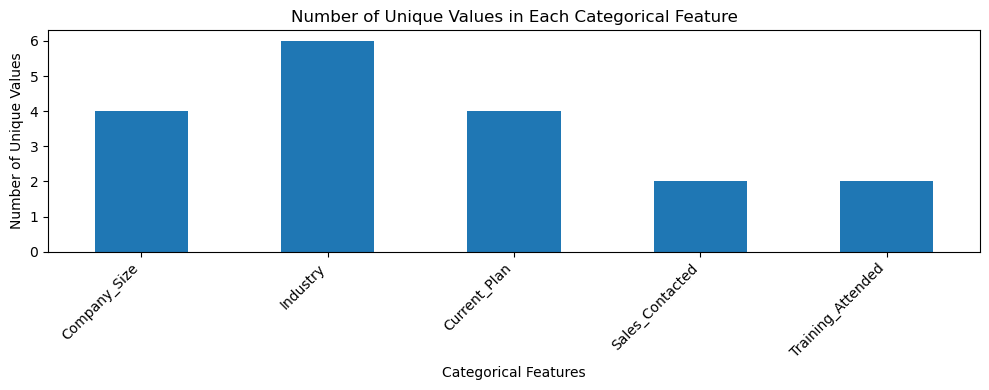

In [28]:
# Create a figure for the categorical unique values chart
plt.figure(figsize=(10, 4))

# Create a bar chart for the number of unique values in each categorical feature
categorical_unique_counts.plot(kind="bar")

# Add a title to the chart
plt.title("Number of Unique Values in Each Categorical Feature")

# Add a label to the x-axis
plt.xlabel("Categorical Features")

# Add a label to the y-axis
plt.ylabel("Number of Unique Values")

# Rotate x-axis labels to make them easier to read
plt.xticks(rotation=45, ha="right")

# Adjust the layout so labels do not overlap
plt.tight_layout()

# Save the chart in the outputs folder
plt.savefig("outputs/categorical_unique_values.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

### Short Interpretation

The graph shows the number of unique categories in each categorical feature. This helps identify how much variety exists in the text-based columns before preprocessing.

Since Logistic Regression and SVM require numerical input, categorical variables must be converted into numerical format before model training. In this notebook, one-hot encoding will be used for this conversion.


## Step 8: Define X and y

In this step, we separate the cleaned dataset into input features and the target variable.

The target variable is Upgraded_Account. This is the column that the models are trying to predict.

The feature variables are the input columns that the models use to learn patterns and make predictions. The Account_ID column is removed because it is only an identification number and does not provide meaningful information for predicting account upgrades.

Therefore:
- X contains the feature variables used to make predictions.
- y contains the target variable, Upgraded_Account.

After this step, X will contain the input data, and y will contain the correct answer that the models need to learn from.
The remaining columns are used as input features.

In [29]:
# Create X by removing the target column and ID column
X = df_clean.drop(columns=[target_column, id_column])

# Create y by selecting the target column
y = df_clean[target_column]

# Print a message to confirm that X and y have been created
print("X and y have been defined successfully.\n")

# Select numerical feature columns from X
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()

# Select categorical feature columns from X
categorical_features = X.select_dtypes(include=["object","string"]).columns.tolist()

# Print X and y shapes
print("Features and Target Shapes")
print("-" * 50)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("-" * 50)
print("\nThe first five rows of X")
# Display the first five rows of X
display(X.head())
print("\n")
print("-" * 50)
print("The first five rows of y")
# Display the first five rows of Y
display(y.head())

X and y have been defined successfully.

Features and Target Shapes
--------------------------------------------------
X shape: (370, 11)
y shape: (370,)
--------------------------------------------------

The first five rows of X


,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended
0,Small,Healthcare,4765975.0,368,Business,26,5,No,55.0,2832,Yes
1,Small,Manufacturing,5683548.0,257,Basic,75,4,No,5.0,1215,Yes
2,Enterprise,Manufacturing,1722517.0,424,Premium,99,0,No,64.0,753,No
3,Enterprise,Education,3481277.0,190,Standard,33,0,Yes,86.0,1973,No
4,Small,Finance,1023375.0,262,Basic,52,3,No,88.0,3676,Yes




--------------------------------------------------
The first five rows of y


0     No
1     No
2     No
3    Yes
4     No
Name: Upgraded_Account, dtype: str

In [30]:
# Print target class distribution after cleaning
print("Target Class Distribution After Cleaning")
print("-" * 50)

target_counts_clean = y.value_counts()
display(target_counts_clean)

Target Class Distribution After Cleaning
--------------------------------------------------


Upgraded_Account
No     288
Yes     82
Name: count, dtype: int64

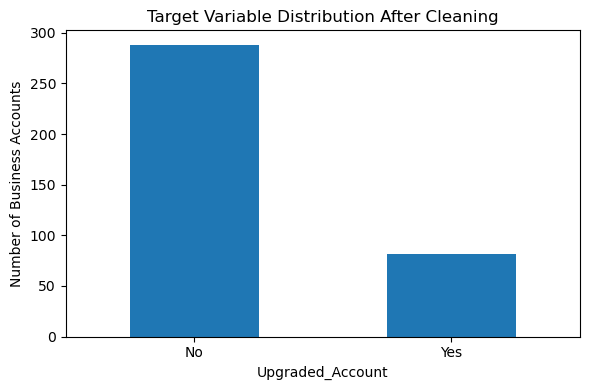

In [31]:
# Create a figure for the target distribution chart after cleaning
plt.figure(figsize=(6, 4))

# Create a bar chart for the cleaned target variable distribution
target_counts_clean.plot(kind="bar")

# Add a title to the chart
plt.title("Target Variable Distribution After Cleaning")

# Add a label to the x-axis
plt.xlabel("Upgraded_Account")

# Add a label to the y-axis
plt.ylabel("Number of Business Accounts")

# Rotate x-axis labels to make them easier to read
plt.xticks(rotation=0)

# Adjust layout to avoid overlap
plt.tight_layout()

# Save the chart
plt.savefig("outputs/target_distribution_after_cleaning.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

### Short Interpretation

The model input features are stored in X, and the target variable is stored in y. The identifier column Account_ID has been removed before model training to avoid giving the models an unhelpful ID value.

The dataset is now separated into the inputs the models will learn from and the outcome they will try to predict.

## Step 9: Train/Test Split

In this step, the dataset is split into training and testing sets.

The training set is used to train the Logistic Regression and SVM models. The testing set is kept separate and used to evaluate how well the models perform on unseen business account records.

This step is important because model performance should not be measured only on the same data used for training. Testing the models on unseen data helps us understand whether they can generalize to new business accounts.

In this notebook, the dataset is split as follows:

* 80% of the data is used for training.
* 20% of the data is used for testing.
* `random_state=42` is used to make the split reproducible.
* `stratify=y` is used to keep the `Yes` and `No` target class distribution similar in both the training and testing sets.

Using a stratified split is useful because it helps both sets represent the original target distribution more fairly.


In [32]:
# Split X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create a table showing the shape of each dataset
split_summary = pd.DataFrame({
    "Dataset": ["X_train", "X_test", "y_train", "y_test"],
    "Shape": [X_train.shape, X_test.shape, y_train.shape, y_test.shape]
})
# Print a message to confirm that the data has been split
print("Data has been split into training and testing sets.\n")

# Display split summary
display(split_summary)

Data has been split into training and testing sets.



,Dataset,Shape
0,X_train,"(296, 11)"
1,X_test,"(74, 11)"
2,y_train,"(296,)"
3,y_test,"(74,)"


In [33]:
# Compare target distribution in training and testing sets
split_target_distribution = pd.DataFrame({
    "Training Set": y_train.value_counts().sort_index(),
    "Testing Set": y_test.value_counts().sort_index()
})

# Display the target distribution in training and testing sets
display(split_target_distribution)

,Training Set,Testing Set
Upgraded_Account,,
No,230,58
Yes,66,16


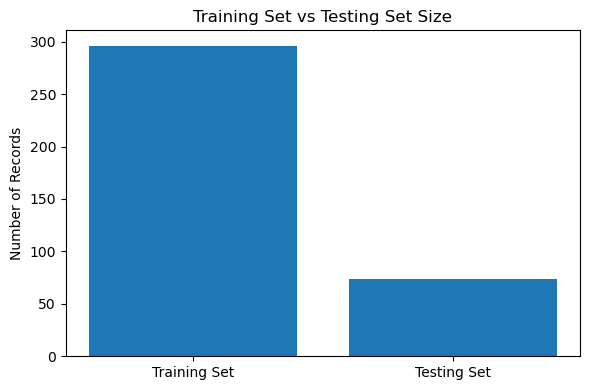

In [34]:
# Create labels for the chart
split_labels = ["Training Set", "Testing Set"]

# Create values for the chart
split_sizes = [len(X_train), len(X_test)]

# Create a figure for the chart
plt.figure(figsize=(6, 4))

# Create a bar chart for train and test size
plt.bar(split_labels, split_sizes)

# Add a title to the chart
plt.title("Training Set vs Testing Set Size")

# Add a label to the y-axis
plt.ylabel("Number of Records")

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

## Step 10: Preprocessing

In this step, preprocessing is prepared for the input features before training the Logistic Regression and SVM models.

The dataset contains both numerical and categorical variables, so different preprocessing methods are needed for each feature type.

### Numerical Features

Numerical features contain number-based values such as annual revenue, monthly transactions, account age, support tickets, product usage score, and monthly fee.

For numerical features:

* Missing values are filled using the median.
* The values are scaled using `StandardScaler`.

Scaling is important for Logistic Regression and SVM because these models can be affected by differences in feature ranges.

### Categorical Features

Categorical features contain text-based values such as company size, industry, current plan, sales contact status, and training attendance.

For categorical features:

* Missing values are filled using the most frequent category.
* The categories are converted into numerical columns using `OneHotEncoder`.

This conversion is necessary because machine learning models cannot directly use text-based categories.

### Why Preprocessing Is Included in the Pipeline

The preprocessing steps are placed inside the model pipeline. This means imputation, scaling, and encoding are learned from the training data and then applied to the testing data.

This is a safer modeling practice because it helps avoid data leakage and keeps the training and testing process properly separated.


In [35]:
    # Step 10: Preprocessing
    
    # Identify numerical feature columns from X
    numerical_features = X.select_dtypes(include=["number"]).columns.tolist()
    
    # Identify categorical feature columns from X
    categorical_features = X.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()
    
    # Display numerical and categorical features
    print("Numerical Features:")
    print(numerical_features)
    
    print("\nCategorical Features:")
    print(categorical_features)
    
    # Create preprocessing steps for numerical features
    # Missing numerical values are handled here using median imputation
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    
    # Create preprocessing steps for categorical features
    # Missing categorical values are handled here using most frequent value imputation
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    
    # Combine numerical and categorical preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numerical_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )
    
    # Print confirmation message
    print("Preprocessing pipeline created successfully.")
    print("Numerical features will be imputed and scaled.")
    print("Categorical features will be imputed and one-hot encoded.")

Numerical Features:
['Annual_Revenue', 'Monthly_Transactions', 'Account_Age_Months', 'Support_Tickets', 'Product_Usage_Score', 'Monthly_Fee']

Categorical Features:
['Company_Size', 'Industry', 'Current_Plan', 'Sales_Contacted', 'Training_Attended']
Preprocessing pipeline created successfully.
Numerical features will be imputed and scaled.
Categorical features will be imputed and one-hot encoded.


## Step 11: Building a Baseline Model with Logistic Regression

In this step, we build the first classification model using Logistic Regression.

Logistic Regression is used as the baseline model because it is simple, commonly used, and suitable for binary classification problems. A baseline model provides an initial performance level that can be compared with another model.

Although the word “regression” appears in its name, Logistic Regression is used here for classification because the target variable, `Upgraded_Account`, has two possible classes: `Yes` and `No`.

In this assignment, the Logistic Regression model predicts whether a business account will upgrade or not. The model is placed inside a pipeline with the preprocessing steps so that missing-value handling, scaling, encoding, and model training are completed in one organized workflow.

In [36]:
# Step 11: Build and Train Logistic Regression Model

# Create Logistic Regression pipeline
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Train the Logistic Regression model
logistic_model.fit(X_train, y_train)

# Print confirmation message
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Step 12: Building SVM as a Comparison Model

In this step, we build the second classification model using Support Vector Machine, also called SVM.

SVM is used as a comparison model because it is another common classification algorithm. It works by finding a decision boundary that separates the classes as clearly as possible.

In this assignment, the SVM model predicts whether a business account will upgrade or not. The results from the SVM model will be compared with the Logistic Regression baseline model.

The SVM model is also placed inside a pipeline with the same preprocessing steps. This ensures that both models use the same data preparation process, making the comparison fair and consistent.


In [37]:
# Step 12: Build and Train SVM Model

# Create SVM pipeline
svm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(kernel="rbf", random_state=42))
])

# Train the SVM model
svm_model.fit(X_train, y_train)

# Print confirmation message
print("SVM model trained successfully.")

SVM model trained successfully.


## Step 13: Model Prediction

After training the Logistic Regression and SVM models, we use the testing data to make predictions.

The testing data was not used during model training. Therefore, it helps us evaluate how well each model performs on unseen business account records.

In this step, each trained model predicts whether the accounts in the testing set belong to the `Yes` class or the `No` class. These predicted values are then compared with the actual values in `y_test`.

The prediction results will be used in the next step to calculate the confusion matrix, accuracy, precision, recall, and F1-score for both models.


In [38]:
# Step 13: Model Prediction

# Create testing predictions
y_pred_logistic = logistic_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

# Create training predictions
y_train_pred_logistic = logistic_model.predict(X_train)
y_train_pred_svm = svm_model.predict(X_train)

# Print confirmation message
print("Predictions created successfully.")

Predictions created successfully.


In [39]:
# Display the first ten predictions from both models
print("First 10 Logistic Regression predictions:")
print(y_pred_logistic[:10])

print("-" * 50)

print("First 10 SVM predictions:")
print(y_pred_svm[:10])

First 10 Logistic Regression predictions:
['No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No']
--------------------------------------------------
First 10 SVM predictions:
['No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No']


## Step 14: Model Evaluation and Comparison

In this step, the Logistic Regression and SVM models are evaluated and compared using the testing data.

The testing data was not used during training, so it helps us understand how well each model performs on unseen business account records.

The required evaluation metrics are:

1. Confusion matrix
2. Accuracy
3. Precision
4. Recall
5. F1-score

The confusion matrix shows the number of correct and incorrect predictions for each class. Accuracy shows the overall percentage of correct predictions. Precision shows how many accounts predicted as `Yes` were actually upgraded. Recall shows how many actual `Yes` upgrade accounts were correctly identified by the model. F1-score combines precision and recall into one balanced metric.

After calculating these metrics for both models, the results are compared side by side. This comparison helps identify the strengths and weaknesses of each model.

The best model is not always the one with the highest accuracy. For this business account upgrade prediction problem, the selected model should also identify actual upgrade opportunities effectively and avoid too many incorrect upgrade predictions.

By comparing Logistic Regression and SVM using the same evaluation metrics, we can decide which model performs better and which model is more useful for supporting business decisions.

In [40]:
# Step 14: Create a function to evaluate classification models

def evaluate_model(model_name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    """
    Evaluate a classification model and return a dictionary of metrics.
    The positive class is 'Yes'.
    """
    
    labels = ["No", "Yes"]

    # Calculate training and testing accuracy
    train_accuracy = accuracy_score(y_train_true, y_train_pred)
    test_accuracy = accuracy_score(y_test_true, y_test_pred)

    # Calculate metrics for the Yes class
    precision_yes = precision_score(
        y_test_true, y_test_pred, pos_label="Yes", zero_division=0
    )
    
    recall_yes = recall_score(
        y_test_true, y_test_pred, pos_label="Yes", zero_division=0
    )
    
    f1_yes = f1_score(
        y_test_true, y_test_pred, pos_label="Yes", zero_division=0
    )

    # Create confusion matrix
    cm = confusion_matrix(y_test_true, y_test_pred, labels=labels)

    # Print model evaluation results
    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print("Training Accuracy:", round(train_accuracy, 4))
    print("Testing Accuracy:", round(test_accuracy, 4))
    print("Precision for Yes:", round(precision_yes, 4))
    print("Recall for Yes:", round(recall_yes, 4))
    print("F1-score for Yes:", round(f1_yes, 4))
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test_true, y_test_pred, labels=labels, zero_division=0))

    # Return results as a dictionary
    return {
        "Model": model_name,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy,
        "Accuracy": test_accuracy,
        "Precision for Yes": precision_yes,
        "Recall for Yes": recall_yes,
        "F1-score for Yes": f1_yes
    }

In [41]:
# Create training predictions
y_train_pred_logistic = logistic_model.predict(X_train)
y_train_pred_svm = svm_model.predict(X_train)

# Evaluate both models
logistic_results = evaluate_model(
    "Logistic Regression",
    y_train,
    y_train_pred_logistic,
    y_test,
    y_pred_logistic
)

svm_results = evaluate_model(
    "SVM",
    y_train,
    y_train_pred_svm,
    y_test,
    y_pred_svm
)

# Create model comparison DataFrame
results_df = pd.DataFrame([logistic_results, svm_results])

# Display model comparison table
display(results_df)

# Save model comparison results
results_df.to_csv(
    outputs_dir / "model_comparison_results.csv",
    index=False
)

Logistic Regression
Training Accuracy: 0.8986
Testing Accuracy: 0.7703
Precision for Yes: 0.4545
Recall for Yes: 0.3125
F1-score for Yes: 0.3704

Confusion Matrix:
[[52  6]
 [11  5]]

Classification Report:
              precision    recall  f1-score   support

          No       0.83      0.90      0.86        58
         Yes       0.45      0.31      0.37        16

    accuracy                           0.77        74
   macro avg       0.64      0.60      0.61        74
weighted avg       0.75      0.77      0.75        74

SVM
Training Accuracy: 0.9358
Testing Accuracy: 0.8243
Precision for Yes: 0.7143
Recall for Yes: 0.3125
F1-score for Yes: 0.4348

Confusion Matrix:
[[56  2]
 [11  5]]

Classification Report:
              precision    recall  f1-score   support

          No       0.84      0.97      0.90        58
         Yes       0.71      0.31      0.43        16

    accuracy                           0.82        74
   macro avg       0.78      0.64      0.67        74
wei

,Model,Training Accuracy,Testing Accuracy,Accuracy,Precision for Yes,Recall for Yes,F1-score for Yes
0,Logistic Regression,0.898649,0.770270,0.770270,0.454545,0.3125,0.370370
1,SVM,0.935811,0.824324,0.824324,0.714286,0.3125,0.434783


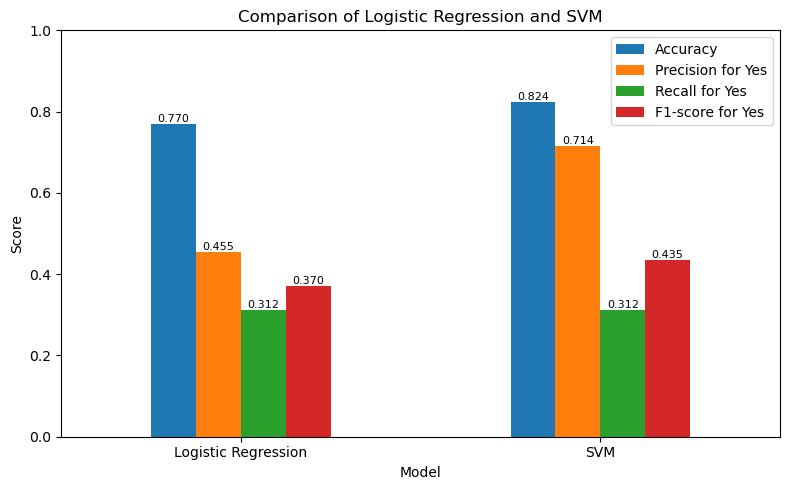

In [42]:
# Create a bar chart to compare the models

# Select the model evaluation metrics for plotting
plot_df = results_df.set_index("Model")[[
    "Accuracy",
    "Precision for Yes",
    "Recall for Yes",
    "F1-score for Yes"
]]

# Create a bar chart
ax = plot_df.plot(
    kind="bar",
    figsize=(8, 5)
)

# Add chart title and labels
plt.title("Comparison of Logistic Regression and SVM")
plt.xlabel("Model")
plt.ylabel("Score")

# Set y-axis range
plt.ylim(0, 1)

# Rotate x-axis labels
plt.xticks(rotation=0)

# Add values above each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)

# Adjust layout
plt.tight_layout()

# Save the chart
plt.savefig(
    outputs_dir / "model_comparison_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

# Display chart
plt.show()

## 14.1 Confusion Matrix Visualization and Comparison

A confusion matrix shows the correct and incorrect predictions made by each model. It helps us understand not only how many predictions were correct, but also what types of errors the models made.

For this assignment, the positive class is `Yes`, which means the business account upgraded.

The confusion matrix is interpreted as follows:

* **True Negative:** Actual `No`, predicted `No`
* **False Positive:** Actual `No`, predicted `Yes`
* **False Negative:** Actual `Yes`, predicted `No`
* **True Positive:** Actual `Yes`, predicted `Yes`

In the business account upgrade prediction problem, a false positive means the model predicts that an account will upgrade, but the account actually does not upgrade. This may cause the company to spend sales or marketing resources on an account that is less likely to upgrade.

A false negative means the model predicts that an account will not upgrade, but the account actually upgrades. This may cause the company to miss a real upgrade opportunity.

By comparing the confusion matrices of Logistic Regression and SVM, we can see which model makes fewer classification errors and which model is better at identifying actual upgraded accounts.


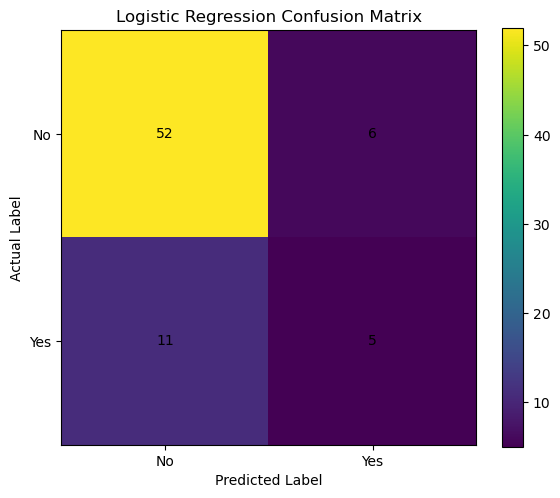

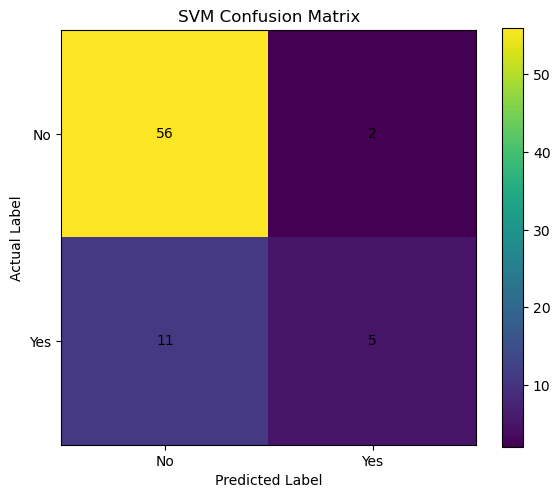

In [43]:
# Create confusion matrices using actual and predicted values
logistic_cm = confusion_matrix(
    y_test,
    y_pred_logistic,
    labels=["No", "Yes"]
)

svm_cm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=["No", "Yes"]
)

# Create a function to plot and save confusion matrix
def plot_confusion_matrix(cm, model_name, file_name):
    
    # Define class labels
    labels = ["No", "Yes"]

    # Create the figure
    plt.figure(figsize=(6, 5))

    # Create the confusion matrix chart
    plt.imshow(cm)

    # Add title and axis labels
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    # Add tick labels
    plt.xticks(ticks=[0, 1], labels=labels)
    plt.yticks(ticks=[0, 1], labels=labels)

    # Add color bar
    plt.colorbar()

    # Add values inside each cell
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    # Adjust layout
    plt.tight_layout()

    # Save the chart
    plt.savefig(file_name, dpi=300, bbox_inches="tight")

    # Display the chart
    plt.show()

# Plot and save Logistic Regression confusion matrix
plot_confusion_matrix(
    logistic_cm,
    "Logistic Regression",
    "outputs/logistic_regression_confusion_matrix.png"
)

# Plot and save SVM confusion matrix
plot_confusion_matrix(
    svm_cm,
    "SVM",
    "outputs/svm_confusion_matrix.png"
)

In [44]:
# False Positives and False Negatives Summary

# Create a function to extract business meaning from a confusion matrix
def confusion_matrix_business_summary(cm, model_name):
    
    # Extract values from the confusion matrix
    tn = cm[0, 0]  # Actual No, Predicted No
    fp = cm[0, 1]  # Actual No, Predicted Yes
    fn = cm[1, 0]  # Actual Yes, Predicted No
    tp = cm[1, 1]  # Actual Yes, Predicted Yes

    # Return the results as a dictionary
    return {
        "Model": model_name,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp
    }

# Create a summary table for both models
error_summary = pd.DataFrame([
    confusion_matrix_business_summary(logistic_cm, "Logistic Regression"),
    confusion_matrix_business_summary(svm_cm, "SVM")
])

# Display the summary table
display(error_summary)

,Model,True Negatives,False Positives,False Negatives,True Positives
0,Logistic Regression,52,6,11,5
1,SVM,56,2,11,5


### Short Interpretation

The confusion matrices and summary table show the correct and incorrect predictions made by each model.

False positives are accounts predicted as upgraded even though they did not upgrade. False negatives are accounts predicted as not upgraded even though they actually upgraded.

From a business perspective, false negatives are important because they represent missed upgrade opportunities. Comparing these values helps identify which model makes fewer business-relevant errors.


## Step 15: Training Accuracy vs Testing Accuracy

Training accuracy and testing accuracy are compared to check whether the model may be overfitting.

- If training accuracy is much higher than testing accuracy, the model may be memorizing the training data.
- If testing accuracy is close to training accuracy, the model is more likely to generalize reasonably well.

,Model,Training Accuracy,Testing Accuracy,Accuracy Gap
0,Logistic Regression,0.898649,0.770270,0.128378
1,SVM,0.935811,0.824324,0.111486


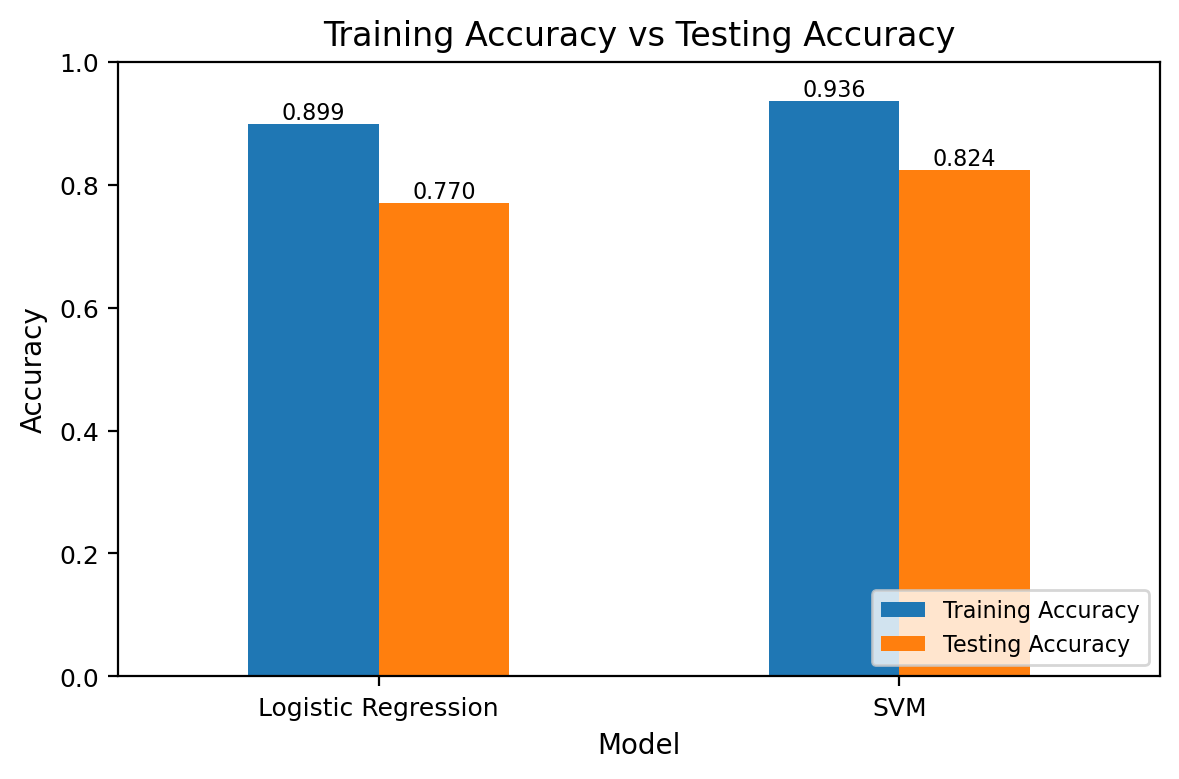

In [45]:
# Step 16: Training and Testing Accuracy Comparison

# Import accuracy_score if not already imported
from sklearn.metrics import accuracy_score

# Make sure the outputs folder exists
outputs_dir.mkdir(exist_ok=True)

# Calculate training and testing accuracy for both models
accuracy_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM"],
    
    "Training Accuracy": [
        accuracy_score(y_train, logistic_model.predict(X_train)),
        accuracy_score(y_train, svm_model.predict(X_train))
    ],
    
    "Testing Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_svm)
    ]
})

# Calculate the difference between training and testing accuracy
accuracy_comparison["Accuracy Gap"] = (
    accuracy_comparison["Training Accuracy"] 
    - accuracy_comparison["Testing Accuracy"]
)

# Display the accuracy comparison table
display(accuracy_comparison)

# Prepare the data for plotting
plot_df = accuracy_comparison.set_index("Model")[[
    "Training Accuracy",
    "Testing Accuracy"
]]

# Create a bar chart to compare training and testing accuracy
ax = plot_df.plot(kind="bar", figsize=(6, 4))

# Add chart title and labels
plt.title("Training Accuracy vs Testing Accuracy", fontsize=12)
plt.xlabel("Model", fontsize=10)
plt.ylabel("Accuracy", fontsize=10)

# Set y-axis range
plt.ylim(0, 1)

# Keep model names horizontal
plt.xticks(rotation=0, fontsize=9)
plt.yticks(fontsize=9)

# Add legend
plt.legend(loc="lower right", fontsize=8)

# Add values above each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)

# Adjust layout
plt.tight_layout()

# Save the chart in the outputs folder
chart_path = outputs_dir / "training_testing_accuracy_comparison.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")

# Close the plot to avoid duplicate display
plt.close()

# Display the saved chart with controlled width
display(Image(filename=str(chart_path), width=600))


In [46]:
# Create a results table for both models
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM"],

    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_svm)
    ],

    "Precision for Yes": [
        precision_score(y_test, y_pred_logistic, pos_label="Yes", zero_division=0),
        precision_score(y_test, y_pred_svm, pos_label="Yes", zero_division=0)
    ],

    "Recall for Yes": [
        recall_score(y_test, y_pred_logistic, pos_label="Yes", zero_division=0),
        recall_score(y_test, y_pred_svm, pos_label="Yes", zero_division=0)
    ],

    "F1-score for Yes": [
        f1_score(y_test, y_pred_logistic, pos_label="Yes", zero_division=0),
        f1_score(y_test, y_pred_svm, pos_label="Yes", zero_division=0)
    ]
})

# Function to identify the best model for each metric
def best_models_for_metric(metric_name):
    
    # Find the best score for the selected metric
    best_value = results_df[metric_name].max()
    
    # Identify all models with the best score
    best_models = results_df.loc[
        np.isclose(results_df[metric_name], best_value),
        "Model"
    ].tolist()
    
    # Return model name(s) and best score
    return " and ".join(best_models), best_value

# Define metrics for comparison
comparison_metrics = [
    "Accuracy",
    "Precision for Yes",
    "Recall for Yes",
    "F1-score for Yes"
]

# Create winner summary rows
winner_rows = []

for metric in comparison_metrics:
    best_model_names, best_value = best_models_for_metric(metric)
    
    winner_rows.append({
        "Metric": metric,
        "Better Model": best_model_names,
        "Best Score": round(best_value, 6)
    })

# Create and display the winner comparison table
winner_df = pd.DataFrame(winner_rows)

display(winner_df)

# Print the model with the highest F1-score for Yes
best_f1_model, best_f1_value = best_models_for_metric("F1-score for Yes")

print("Model with the highest F1-score for Yes:", best_f1_model)

,Metric,Better Model,Best Score
0,Accuracy,SVM,0.824324
1,Precision for Yes,SVM,0.714286
2,Recall for Yes,Logistic Regression and SVM,0.312500
3,F1-score for Yes,SVM,0.434783


Model with the highest F1-score for Yes: SVM


## Step 16: Business Interpretation

### Which model performed better?

Based on the model comparison results, **SVM performed better overall** than Logistic Regression.

SVM achieved the highest **accuracy** of **0.824324**, meaning it correctly classified about **82.43%** of the testing records. SVM also achieved the highest **precision for the Yes class** at **0.714286**, meaning that when SVM predicted an account as upgraded, it was correct about **71.43%** of the time.

Both Logistic Regression and SVM achieved the same **recall for the Yes class** of **0.312500**. This means both models identified only **31.25%** of the actual upgraded accounts. However, SVM had the higher **F1-score for the Yes class** at **0.434783**, which shows that SVM provides a better balance between precision and recall.

Therefore, **SVM is the stronger model in this assignment**, mainly because it has higher accuracy, higher precision, and higher F1-score than Logistic Regression.

### Which metric is most important for the business problem?

For this business account upgrade prediction problem, **recall for the Yes class is very important** because the company wants to identify accounts that actually upgraded.

A low recall means the model misses many actual upgrade accounts. In this result, both models have a recall of **0.312500**, meaning they identify only about **31.25%** of actual upgraded accounts. This shows that both models still have difficulty finding all real upgrade opportunities.

However, **F1-score is also important** because it balances recall and precision. Since SVM has the better F1-score of **0.434783**, it is the better overall model for this dataset.

### What do false positives and false negatives mean in this dataset?

A **false positive** means the model predicts that a business account will upgrade, but the account does not actually upgrade. In business terms, this may cause the company to spend sales or marketing effort on an account that is not truly likely to upgrade.

A **false negative** means the model predicts that a business account will not upgrade, but the account actually upgrades. In business terms, this is a missed opportunity because the company may fail to identify and support a real potential upgrade customer.

Because both models have low recall for the Yes class, missed upgrade opportunities are an important concern in this project.

### What is one possible limitation or bias in the model?

One possible limitation is **class imbalance**. If the dataset contains more `No` upgrade cases than `Yes` upgrade cases, the models may become better at predicting non-upgraded accounts and weaker at identifying upgraded accounts.

This is reflected in the recall result. Both models identified only **31.25%** of actual upgraded accounts, showing that the models may not be strong enough at detecting the minority or more difficult class.

Another limitation is that the dataset may not include all business factors that influence account upgrades, such as customer satisfaction, contract renewal timing, budget availability, competitor offers, or detailed sales conversations.

### Why should human judgment still be used?

Human judgment should still be used because the models can make incorrect predictions and do not fully understand business context.

For example, an account may be predicted as unlikely to upgrade, but a sales manager may know that the customer is planning expansion. Another account may be predicted as likely to upgrade, but budget problems or contract issues may prevent the upgrade.

Therefore, the model should be used as a **decision-support tool**, not as the only basis for business decisions. Sales and customer success teams should combine model predictions with account history, customer conversations, and professional judgment.


## 17. Final Conclusion

This notebook trained and compared two classification models, Logistic Regression and SVM, to predict whether a business account would upgrade its account.

The workflow included understanding the business problem, loading and inspecting the dataset, cleaning duplicate records, identifying numerical and categorical variables, defining the input features and target variable, splitting the data into training and testing sets, applying preprocessing, training both models, making predictions, and evaluating the results using confusion matrix, accuracy, precision, recall, and F1-score.

Based on the results, **SVM performed better overall** than Logistic Regression. SVM achieved the highest accuracy of **0.824324**, the highest precision for the `Yes` class of **0.714286**, and the highest F1-score for the `Yes` class of **0.434783**. Both Logistic Regression and SVM achieved the same recall for the `Yes` class of **0.312500**.

From a business perspective, SVM is the preferred model in this notebook because it provides stronger overall performance and a better balance between precision and recall. However, the recall score shows that both models still missed many actual upgraded accounts. This means the models may not identify all possible upgrade opportunities.

Therefore, the model should be used as a decision-support tool rather than as the only basis for business decisions. Sales and customer success teams should combine model predictions with customer history, account context, professional judgment, and fairness considerations before taking action.


In [47]:
# Step 19: Final Model Comparison Summary

# Display the final model comparison table
print("Final Model Comparison Summary:")
display(results_df)

# Print column names to confirm available columns
print("Columns in results_df:")
print(results_df.columns.tolist())

# Identify the best model for each testing metric
best_accuracy_model = results_df.loc[
    results_df["Accuracy"].idxmax(), "Model"
]

best_precision_model = results_df.loc[
    results_df["Precision for Yes"].idxmax(), "Model"
]

best_recall_model = results_df.loc[
    results_df["Recall for Yes"].idxmax(), "Model"
]

best_f1_model = results_df.loc[
    results_df["F1-score for Yes"].idxmax(), "Model"
]

# Print best model by each metric
print("Best Model by Accuracy:", best_accuracy_model)
print("Best Model by Precision for Yes:", best_precision_model)
print("Best Model by Recall for Yes:", best_recall_model)
print("Best Model by F1-score for Yes:", best_f1_model)

# Count how many times each model was selected as best
best_models = [
    best_accuracy_model,
    best_precision_model,
    best_recall_model,
    best_f1_model
]

best_model_counts = pd.Series(best_models).value_counts()

# Identify the overall stronger model
overall_best_model = best_model_counts.idxmax()

# Print final conclusion
print("-" * 60)
print("Overall Stronger Model:", overall_best_model)
print("-" * 60)

print(
    f"Based on the model comparison table, {overall_best_model} is selected "
    f"as the stronger overall model because it performs better across more "
    f"evaluation metrics. However, recall for the Yes class should still be "
    f"interpreted carefully because false negatives represent missed upgrade "
    f"opportunities for the business."
)

Final Model Comparison Summary:


,Model,Accuracy,Precision for Yes,Recall for Yes,F1-score for Yes
0,Logistic Regression,0.770270,0.454545,0.3125,0.370370
1,SVM,0.824324,0.714286,0.3125,0.434783


Columns in results_df:
['Model', 'Accuracy', 'Precision for Yes', 'Recall for Yes', 'F1-score for Yes']
Best Model by Accuracy: SVM
Best Model by Precision for Yes: SVM
Best Model by Recall for Yes: Logistic Regression
Best Model by F1-score for Yes: SVM
------------------------------------------------------------
Overall Stronger Model: SVM
------------------------------------------------------------
Based on the model comparison table, SVM is selected as the stronger overall model because it performs better across more evaluation metrics. However, recall for the Yes class should still be interpreted carefully because false negatives represent missed upgrade opportunities for the business.
